# Training Cohort — Coronal Deformity Distribution

Measures the **alignment range the model was actually trained on**, by computing HKA directly
from the ground-truth annotations of the Mendeley long-leg dataset
([10.17632/bpvj6xczm2.1](https://doi.org/10.17632/bpvj6xczm2.1)) — the same 54 radiographs and
the same three-observer-mean landmarks used in `hto_correction_angles.ipynb`.

**Why this notebook exists.** `hto_oai_deformity_stratified_validation.ipynb` reports OAI
performance split into varus / normal / valgus, and interprets the split against a training
domain that has never been quantified anywhere — not in the manuscript, and not on the Mendeley
record, which says only "patients with leg deformity" and reports no alignment measurements. So
the claim "varus is in-domain, valgus is extrapolation" currently rests on the surgical
indication alone. This notebook replaces that inference with a measurement.

### How it stays faithful to the training pipeline

- **Same limbs.** The annotation loader here reproduces `GlobalRadiographKeypointDataset`
  from `hto_correction_angles.ipynb` exactly: per-category grouping, hemisphere assignment by
  *relative* representative x (smaller → image-left slots 0–5, larger → image-right slots 6–11),
  the single-annotation midpoint fallback, and the same visibility rules. A limb that the loader
  would drop is dropped here too.
- **Same split.** The deterministic `sort → seed(42) → shuffle → 80/10/10` is reproduced, so the
  distribution can be reported per split.
- **Same geometry.** `hka_from_side()` is the function used in both OAI notebooks, so training
  and validation HKA are on one scale and one sign convention (OAISYS: signed, 0 = neutral,
  negative = varus). `miniaci_correction_angle()` is taken from
  `hto_interobserver_angle_analysis.ipynb`.
- **Same class rule.** `varus < −NEUTRAL_BAND`, `|HKA| ≤ NEUTRAL_BAND`, `valgus > +NEUTRAL_BAND`,
  default 3.0°.

### What it produces

- per-limb HKA and deformity class, with the cohort's range, quartiles and class counts
- **inter-observer HKA agreement** from the three specialists' separate annotations — the
  annotation noise floor, in the same units as OAI's 0.30° reader SD
- the Miniaci correction-angle distribution, and how it tracks HKA
- **the domain-overlap figure**: training HKA against the OAI cohort, with the stratum cut-offs
  and the model's compression fixed point marked — the figure the external-validation section is
  missing
- split-wise composition, a band sweep, exported tables, and a verification cell

## 1 · Configuration

In [1]:
import os
import json
import math
import random
import itertools
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- the training annotations (same default as hto_correction_angles.ipynb) ----
DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

# ---- optional: the OAI cohort, for the domain-overlap section -----------------
# First hit wins. knee_results.csv comes out of the stratified validation notebook;
# oai_hka_groundtruth.csv comes out of scripts/prepare_oai_hka.py.
OAI_CANDIDATES = [
    "oai_deformity_stratified/knee_results.csv",
    "/tf/data/hka/oai_hka_groundtruth.csv",
]
OAI_SUMMARY_JSON = "oai_deformity_stratified/summary.json"   # for the compression fixed point

OUT_DIR = "training_cohort_deformity"

# ---- split reproduction (must match hto_correction_angles.ipynb) --------------
SEED         = 42
SPLIT_RATIOS = (0.8, 0.1, 0.1)

# ---- stratification (must match the validation notebook) ----------------------
NEUTRAL_BAND    = 3.0
CLASSES         = ("varus", "normal", "valgus")
BAND_SWEEP      = (1.0, 2.0, 3.0, 4.0, 5.0)
HKA_NEUTRAL_180 = False
HKA_SIGN_FLIP   = False
NEUTRAL         = 180.0 if HKA_NEUTRAL_180 else 0.0

FUJISAWA_RATIO    = 0.625
SPECIALIST_FIELDS = ["keypoints_specialist1", "keypoints_specialist2", "keypoints_specialist3"]
SPECIALIST_LABELS = ["S1", "S2", "S3"]

PALETTE = {"varus": "#B3572B", "normal": "#4C6EB1", "valgus": "#2E7D32",
           "training": "#6B4E9B", "oai": "#8A8A8A"}

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Annotations : {COCO_JSON_PATH}  ({'found' if os.path.exists(COCO_JSON_PATH) else 'MISSING'})")
print(f"Strata      : varus < {NEUTRAL - NEUTRAL_BAND:+.1f} | "
      f"normal {NEUTRAL - NEUTRAL_BAND:+.1f}..{NEUTRAL + NEUTRAL_BAND:+.1f} | "
      f"valgus > {NEUTRAL + NEUTRAL_BAND:+.1f}   (deg)")
print(f"Results     : {os.path.abspath(OUT_DIR)}")

Annotations : /tf/data/hto/xrays/hto_annotations.json  (found)
Strata      : varus < -3.0 | normal -3.0..+3.0 | valgus > +3.0   (deg)
Results     : /tf/notebooks/training_cohort_deformity


## 2 · Geometry

`hka_from_side()` is copied unchanged from the OAI notebooks so training and validation HKA are
directly comparable. `miniaci_correction_angle()` is copied from
`hto_interobserver_angle_analysis.ipynb`.

In [2]:
SIDE_KEYS = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]

# Slots within each hemisphere: 0 femur_head | 1 knee_inner | 2 ost_point | 3 knee_outer
#                               4 ankle_inner | 5 ankle_outer   (ost_point unused for HKA)
def hka_from_side(pts6, neutral180=None, sign_flip=None):
    if neutral180 is None: neutral180 = HKA_NEUTRAL_180
    if sign_flip is None:  sign_flip  = HKA_SIGN_FLIP
    fh = pts6[0]; ki = pts6[1]; ko = pts6[3]
    kc = 0.5 * (ki + ko); ac = 0.5 * (pts6[4] + pts6[5])
    vf = fh - kc; vt = ac - kc                                  # knee->hip, knee->ankle
    cross = vf[0]*vt[1] - vf[1]*vt[0]; dot = vf[0]*vt[0] + vf[1]*vt[1]
    ang = abs(math.degrees(math.atan2(cross, dot)))             # ~180 for a straight leg
    dev = 180.0 - ang
    # laterality-consistent sign: knee_outer(lateral) - knee_inner(medial) is THIS leg's
    # medial->lateral direction, so the same clinical deformity gets the same sign on the
    # left and right legs (their raw cross-product signs are mirror-opposite otherwise).
    lat  = 1.0 if (ko[0] - ki[0]) >= 0 else -1.0
    sign = (-1.0 if cross < 0 else 1.0) * lat * (-1.0 if sign_flip else 1.0)
    return (180.0 - sign*dev) if neutral180 else (sign*dev)


def miniaci_correction_angle(pts6, ratio=None):
    """Miniaci correction angle (deg) from one limb's 6 landmarks, in slot order."""
    ratio = FUJISAWA_RATIO if ratio is None else ratio
    if pts6 is None or np.isnan(pts6).any():
        return np.nan
    fh, ki, op, ko, ai, ao = (np.asarray(p, float) for p in pts6)
    ankle_c  = (ai + ao) / 2.0
    fujisawa = ki + ratio * (ko - ki)
    dy, dx   = fujisawa[1] - fh[1], fujisawa[0] - fh[0]
    if abs(dy) < 1e-9:
        return np.nan
    target = np.array([fh[0] + (ankle_c[1] - fh[1]) * dx / dy, ankle_c[1]])
    v_o, v_t = ankle_c - op, target - op
    cross = v_o[0]*v_t[1] - v_o[1]*v_t[0]; dot = v_o[0]*v_t[0] + v_o[1]*v_t[1]
    return float(np.degrees(abs(np.arctan2(cross, dot))))


def classify(hka, neutral=None, band=None):
    """Signed HKA -> 'varus' | 'normal' | 'valgus'   (None when missing)."""
    neutral = NEUTRAL if neutral is None else neutral
    band    = NEUTRAL_BAND if band is None else band
    if hka is None or (isinstance(hka, float) and math.isnan(hka)) or pd.isna(hka):
        return None
    dev = float(hka) - neutral
    if dev < -band: return "varus"
    if dev >  band: return "valgus"
    return "normal"


# ---- self-tests ---------------------------------------------------------------
_straight = np.array([[100,0],[90,500],[0,0],[110,500],[90,1000],[110,1000]], float)
assert abs(hka_from_side(_straight, neutral180=True, sign_flip=False) - 180.0) < 0.1
_vL = np.array([[400,100],[415,500],[0,0],[385,500],[450,900],[430,900]], float)
_vR = np.array([[400,100],[385,500],[0,0],[415,500],[350,900],[370,900]], float)
assert abs(hka_from_side(_vL) - hka_from_side(_vR)) < 1e-6, "left/right sign inconsistent"
assert [classify(v) for v in (-NEUTRAL_BAND, 0.0, NEUTRAL_BAND)] == ["normal"] * 3
assert classify(-NEUTRAL_BAND - 0.01) == "varus" and classify(NEUTRAL_BAND + 0.01) == "valgus"
print("geometry + classify self-tests passed.")

geometry + classify self-tests passed.


## 3 · Loading the Annotations the Way the Training Notebook Does

This reproduces `GlobalRadiographKeypointDataset.__init__` from `hto_correction_angles.ipynb`:
annotations grouped by image then by category, hemisphere assigned by *relative* representative x
(smaller → image-left, slots 0–5; larger → image-right, slots 6–11), the midpoint fallback for a
category with a single annotation, `has_kp` filtering, then `sort → seed(42) → shuffle` and the
80/10/10 split. Slots are filled **by keypoint name** where the COCO category names are
recognised, and positionally otherwise — the two are cross-checked in section 4, which is how the
`[knee_inner, ost_point, knee_outer]` ordering the training loader assumes gets verified rather
than trusted.

In [3]:
SLOT_OF = {n: i for i, n in enumerate(SIDE_KEYS)}          # name -> slot within a hemisphere
POSITIONAL = {1: [0], 2: [1, 2, 3], 3: [4, 5]}             # what the training loader assumes

with open(COCO_JSON_PATH, "r") as f:
    coco = json.load(f)

images_info = {im["id"]: im for im in coco.get("images", [])}
cat_names   = {c["id"]: list(c.get("keypoints", [])) for c in coco.get("categories", [])}
anns_by_img = collections.defaultdict(list)
for a in coco.get("annotations", []):
    anns_by_img[a.get("image_id")].append(a)

HAS_SPECIALISTS = all(
    any(f in a for a in coco.get("annotations", [])) for f in SPECIALIST_FIELDS)


def _rep_x(ann):
    """Representative x for hemisphere assignment — verbatim from the training loader."""
    kps = ann.get("keypoints", [])
    xs  = [kps[i] for i in range(0, len(kps), 3) if kps[i] > 0]
    if xs:
        return sum(xs) / len(xs)
    bbox = ann.get("bbox", [0, 0, 0, 0])
    return bbox[0] + bbox[2] / 2


def _fill(kps_flat, ann, base, field, by_name):
    """Write one annotation's keypoints into the 12-slot array."""
    kps   = ann.get(field, [])
    cid   = ann.get("category_id")
    names = cat_names.get(cid, [])
    n_kp  = len(kps) // 3
    used  = False
    for k in range(n_kp):
        if by_name and k < len(names) and names[k] in SLOT_OF:
            slot = base + SLOT_OF[names[k]]
        elif not by_name and cid in POSITIONAL and k < len(POSITIONAL[cid]):
            slot = base + POSITIONAL[cid][k]
        else:
            continue
        x, y, v = kps[3*k], kps[3*k + 1], kps[3*k + 2]
        if cid == 1:                                   # training loader's rule for the femur head
            v = 2 if x > 0 else 0
        kps_flat[slot] = (float(x), float(y), float(v))
        if v > 0:
            used = True
    return used


def build_slots(anns, img_w, field="keypoints", by_name=True):
    """12 (x, y, v) slots for one image, using the training loader's hemisphere logic."""
    slots = [(-1.0, -1.0, 0.0)] * 12
    has_kp = False
    by_cat = collections.defaultdict(list)
    for a in anns:
        by_cat[a.get("category_id")].append(a)
    for cid, cat_anns in by_cat.items():
        ordered = sorted(cat_anns, key=_rep_x)
        if len(ordered) == 2:
            assignments = [(ordered[0], 0), (ordered[1], 6)]
        elif len(ordered) == 1:
            assignments = [(ordered[0], 0 if _rep_x(ordered[0]) < img_w / 2.0 else 6)]
        else:
            assignments = [(ordered[0], 0), (ordered[-1], 6)]
        for ann, base in assignments:
            has_kp |= _fill(slots, ann, base, field, by_name)
    return slots, has_kp


def limb_points(slots, base):
    """6x2 array for one hemisphere; NaN where a landmark is missing."""
    out = np.full((6, 2), np.nan)
    for s in range(6):
        x, y, v = slots[base + s]
        if v > 0 and x >= 0 and y >= 0:
            out[s] = (x, y)
    return out


# ---- reproduce the training loader's sample list, shuffle and split ----
valid_samples = []
for img_id, anns in anns_by_img.items():
    if img_id not in images_info:
        continue
    info  = images_info[img_id]
    img_w = info.get("width", 2860)
    slots, has_kp = build_slots(anns, img_w)
    if not has_kp:
        continue
    valid_samples.append(dict(img_id=img_id, file_name=info.get("file_name"),
                              width=img_w, height=info.get("height", 8000),
                              slots=slots, anns=anns,
                              meta_angle=info.get("correction_angle")))

valid_samples.sort(key=lambda s: s["file_name"])
random.seed(SEED)
random.shuffle(valid_samples)
n = len(valid_samples)
train_end = int(n * SPLIT_RATIOS[0]); val_end = train_end + int(n * SPLIT_RATIOS[1])
for i, s in enumerate(valid_samples):
    s["split"] = "train" if i < train_end else ("val" if i < val_end else "test")

print(f"Images with at least one visible landmark: {n} "
      f"({train_end} train / {val_end - train_end} val / {n - val_end} test)")
print(f"Categories: { {cid: names for cid, names in cat_names.items()} }")
print(f"Per-specialist annotation fields present: {HAS_SPECIALISTS}")

Images with at least one visible landmark: 54 (43 train / 5 val / 6 test)
Categories: {1: ['femur_head'], 2: ['knee_inner', 'ost_point', 'knee_outer'], 3: ['ankle_inner', 'ankle_outer']}
Per-specialist annotation fields present: True


## 4 · Annotation Sanity Checks

Three things would silently corrupt the distribution, so each is checked rather than assumed:
the category keypoint ordering the training loader relies on, the medial/lateral assignment
(swapping `knee_inner` and `knee_outer` flips that limb's HKA sign), and missing landmarks.

In [4]:
issues = []

# --- 1. do the COCO category names match what the training loader assumes positionally? ---
expected = {1: ["femur_head"], 2: ["knee_inner", "ost_point", "knee_outer"],
            3: ["ankle_inner", "ankle_outer"]}
for cid, exp in expected.items():
    got = cat_names.get(cid)
    if got is None:
        issues.append(f"category {cid} absent from the COCO file")
    elif got != exp:
        issues.append(f"category {cid} keypoint order is {got}, training loader assumes {exp}")

# --- 2. name-based and positional slot filling must agree ---
mismatch = 0
for s in valid_samples:
    a, _ = build_slots(s["anns"], s["width"], by_name=True)
    b, _ = build_slots(s["anns"], s["width"], by_name=False)
    if a != b:
        mismatch += 1
if mismatch:
    issues.append(f"{mismatch} image(s) fill differently by name vs by position — "
                  f"the assumed category ordering does not hold")

# --- 3. medial/lateral geometry: on a standing AP film the medial point faces the midline ---
lat_flips = []
for s in valid_samples:
    for base, hemi in ((0, "left"), (6, "right")):
        p = limb_points(s["slots"], base)
        if np.isnan(p[[1, 3]]).any():
            continue
        inner_x, outer_x = p[1][0], p[3][0]
        ok = (inner_x > outer_x) if hemi == "left" else (inner_x < outer_x)
        if not ok:
            lat_flips.append(dict(file_name=s["file_name"], hemisphere=hemi,
                                  knee_inner_x=inner_x, knee_outer_x=outer_x))
LAT_FLIPS = pd.DataFrame(lat_flips)

# --- 4. missing landmarks ---
miss = collections.Counter()
n_limbs = 0
for s in valid_samples:
    for base in (0, 6):
        p = limb_points(s["slots"], base)
        if np.isnan(p).all():
            continue
        n_limbs += 1
        for si, name in enumerate(SIDE_KEYS):
            if np.isnan(p[si]).any():
                miss[name] += 1

print("=" * 78)
print("ANNOTATION SANITY")
print("=" * 78)
print(f"  limbs with at least one landmark : {n_limbs}")
print(f"  slot filling by name == by position: {'yes' if not mismatch else 'NO'}")
print(f"  medial/lateral orientation flips  : {len(LAT_FLIPS)} of {n_limbs} limbs")
if len(LAT_FLIPS):
    print("     (each flips that limb's HKA sign — inspect before trusting its class)")
    print(LAT_FLIPS.head(10).to_string(index=False))
print(f"  missing landmarks by type         : "
      f"{dict(miss) if miss else 'none — every limb fully annotated'}")
if issues:
    print("\n  PROBLEMS:")
    for p in issues:
        print("   x", p)
else:
    print("\n  no structural problems found.")
print("=" * 78)

ANNOTATION SANITY
  limbs with at least one landmark : 108
  slot filling by name == by position: yes
  medial/lateral orientation flips  : 0 of 108 limbs
  missing landmarks by type         : {'femur_head': 1}

  no structural problems found.


## 5 · Per-Limb HKA and Deformity Class

In [5]:
rows = []
for s in valid_samples:
    for base, hemi in ((0, "left"), (6, "right")):
        p = limb_points(s["slots"], base)
        needed = p[[0, 1, 3, 4, 5]]                       # ost_point not used by HKA
        if np.isnan(needed).any():
            continue
        hka  = hka_from_side(p)
        corr = miniaci_correction_angle(p)
        rec  = dict(file_name=s["file_name"], hemisphere=hemi, split=s["split"],
                    hka=hka, deformity=classify(hka), corr_angle=corr,
                    meta_angle=s["meta_angle"])
        if HAS_SPECIALISTS:
            for field, lbl in zip(SPECIALIST_FIELDS, SPECIALIST_LABELS):
                sl, _ = build_slots(s["anns"], s["width"], field=field)
                ps = limb_points(sl, base)
                rec[f"hka_{lbl}"]  = (np.nan if np.isnan(ps[[0, 1, 3, 4, 5]]).any()
                                      else hka_from_side(ps))
                rec[f"corr_{lbl}"] = miniaci_correction_angle(ps)
        rows.append(rec)

LIMBS = pd.DataFrame(rows)
LIMBS["deformity"] = pd.Categorical(LIMBS["deformity"], categories=list(CLASSES), ordered=True)

print(f"{len(LIMBS)} limbs with a complete mechanical axis, "
      f"from {LIMBS['file_name'].nunique()} radiographs.")
print(LIMBS.groupby("deformity", observed=False).size().to_string())
LIMBS.head()

107 limbs with a complete mechanical axis, from 54 radiographs.
deformity
varus     59
normal    34
valgus    14


,file_name,hemisphere,split,hka,deformity,corr_angle,meta_angle,hka_S1,corr_S1,hka_S2,corr_S2,hka_S3,corr_S3
0,58_0.png,left,train,-1.919551,normal,4.587132,1.41,-2.401959,5.130827,-2.021978,4.728180,-2.335976,5.298340
1,58_0.png,right,train,0.515884,normal,2.111111,1.41,0.279293,2.365454,0.348178,2.250802,0.185297,2.669272
2,37_0.png,left,train,0.737708,normal,1.852702,0.74,0.938931,1.707602,0.890781,1.691335,1.156376,1.554927
3,37_0.png,right,train,-0.332792,normal,2.800495,0.74,-0.409379,2.909416,-0.059998,2.436268,-0.529693,3.043460
4,65_0.png,left,train,-1.754772,normal,4.399514,2.32,-1.764428,4.400191,-1.764428,4.400191,-1.246136,4.021007


## 6 · The Distribution

TRAINING COHORT — CORONAL DEFORMITY   (neutral band +/-3.0 deg)
  varus   limbs=  59 ( 55.1%)  HKA  -7.10 +/- 3.47  [-21.61,  -3.06]
  normal  limbs=  34 ( 31.8%)  HKA  -0.74 +/- 1.36  [ -2.92,  +1.70]
  valgus  limbs=  14 ( 13.1%)  HKA  +4.80 +/- 1.48  [ +3.09,  +7.32]
  TOTAL   limbs= 107          HKA  -3.52 +/- 5.12

  percentiles (deg):  min -21.61 | p5 -11.93 | p25 -6.71 | median -3.78 | p75 -0.19 | p95 +4.97 | max +7.32
  full range spanned : -21.61 .. +7.32 deg  (width 28.92 deg)


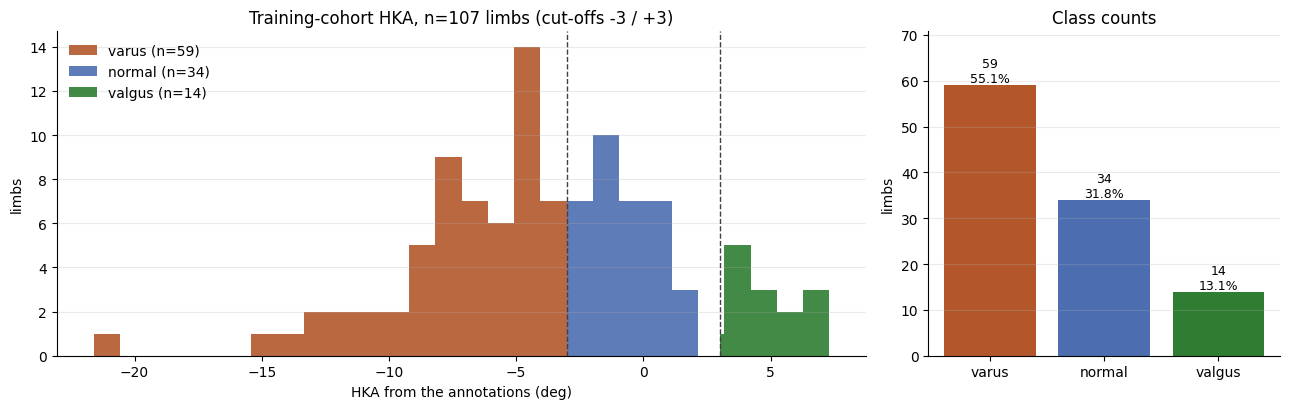

,deformity,limbs,radiographs,hka_mean,hka_sd,hka_min,hka_max,pct
0,varus,59,37,-7.097763,3.472416,-21.606278,-3.060532,55.140187
1,normal,34,26,-0.737758,1.355374,-2.915836,1.699941,31.775701
2,valgus,14,10,4.803166,1.482491,3.092974,7.316518,13.084112


In [6]:
h = LIMBS["hka"].to_numpy(float)
summary = pd.DataFrame([
    dict(deformity=c,
         limbs=int((LIMBS["deformity"] == c).sum()),
         radiographs=int(LIMBS.loc[LIMBS["deformity"] == c, "file_name"].nunique()),
         hka_mean=LIMBS.loc[LIMBS["deformity"] == c, "hka"].mean(),
         hka_sd=LIMBS.loc[LIMBS["deformity"] == c, "hka"].std(ddof=1),
         hka_min=LIMBS.loc[LIMBS["deformity"] == c, "hka"].min(),
         hka_max=LIMBS.loc[LIMBS["deformity"] == c, "hka"].max())
    for c in CLASSES])
summary["pct"] = 100 * summary["limbs"] / max(len(LIMBS), 1)

q = np.percentile(h, [0, 5, 25, 50, 75, 95, 100])
print("=" * 84)
print(f"TRAINING COHORT — CORONAL DEFORMITY   (neutral band +/-{NEUTRAL_BAND:.1f} deg)")
print("=" * 84)
for _, s in summary.iterrows():
    if s["limbs"]:
        print(f"  {s['deformity']:7s} limbs={int(s['limbs']):4d} ({s['pct']:5.1f}%)  "
              f"HKA {s['hka_mean']:+6.2f} +/- {s['hka_sd']:4.2f}  "
              f"[{s['hka_min']:+6.2f}, {s['hka_max']:+6.2f}]")
    else:
        print(f"  {s['deformity']:7s} limbs=   0 (  0.0%)  -- absent from the training set --")
print(f"  {'TOTAL':7s} limbs={len(LIMBS):4d}          "
      f"HKA {h.mean():+6.2f} +/- {h.std(ddof=1):4.2f}")
print(f"\n  percentiles (deg):  min {q[0]:+.2f} | p5 {q[1]:+.2f} | p25 {q[2]:+.2f} | "
      f"median {q[3]:+.2f} | p75 {q[4]:+.2f} | p95 {q[5]:+.2f} | max {q[6]:+.2f}")
print(f"  full range spanned : {q[0]:+.2f} .. {q[6]:+.2f} deg  (width {q[6] - q[0]:.2f} deg)")
absent = [c for c in CLASSES if int((LIMBS['deformity'] == c).sum()) == 0]
if absent:
    print(f"\n  ABSENT CLASSES: {', '.join(absent)} — the model has never seen these at training time.")
print("=" * 84)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [2.3, 1]})
bins = np.union1d(np.histogram_bin_edges(h, bins=28),
                  [NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND])
for c in CLASSES:
    v = LIMBS.loc[LIMBS["deformity"] == c, "hka"].to_numpy(float)
    if len(v):
        ax1.hist(v, bins=bins, color=PALETTE[c], alpha=0.9, label=f"{c} (n={len(v)})")
for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
    ax1.axvline(cut, color="0.25", ls="--", lw=1)
ax1.set_xlabel("HKA from the annotations (deg)"); ax1.set_ylabel("limbs")
ax1.set_title(f"Training-cohort HKA, n={len(LIMBS)} limbs "
              f"(cut-offs {NEUTRAL-NEUTRAL_BAND:+.0f} / {NEUTRAL+NEUTRAL_BAND:+.0f})")
ax1.legend(frameon=False); ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.25)

ax2.bar(summary["deformity"], summary["limbs"],
        color=[PALETTE[c] for c in summary["deformity"]])
for i, (v, p) in enumerate(zip(summary["limbs"], summary["pct"])):
    ax2.text(i, v, f"{int(v)}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("limbs"); ax2.set_title("Class counts")
ax2.set_ylim(0, max(summary["limbs"].max() * 1.2, 1))
ax2.spines[["top", "right"]].set_visible(False); ax2.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_hka_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
summary

## 7 · Inter-Observer HKA Agreement

The three specialists annotated every limb separately, so the same geometry run on each of them
gives the **annotation noise floor in HKA degrees** — the training-side analogue of OAI's 0.30°
within-knee reader SD. It is the right ceiling to quote when saying how close an automated method
could possibly get on this data.

In [7]:
if not HAS_SPECIALISTS:
    print("Per-specialist fields absent from this COCO file — section skipped.")
    IO_PAIRS, io_sd, io_icc = pd.DataFrame(), np.nan, np.nan
else:
    cols = [f"hka_{l}" for l in SPECIALIST_LABELS]
    C = LIMBS[cols].dropna()
    M = C.to_numpy(float)

    def icc21(X):
        X = np.asarray(X, float); n, k = X.shape; g = X.mean()
        SSR = k * ((X.mean(1) - g) ** 2).sum(); SSC = n * ((X.mean(0) - g) ** 2).sum()
        SSE = ((X - g) ** 2).sum() - SSR - SSC
        MSR = SSR / (n - 1); MSC = SSC / (k - 1); MSE = SSE / ((n - 1) * (k - 1))
        return (MSR - MSE) / (MSR + (k - 1) * MSE + (k / n) * (MSC - MSE))

    rows = []
    for a, b in itertools.combinations(SPECIALIST_LABELS, 2):
        d = (C[f"hka_{a}"] - C[f"hka_{b}"]).to_numpy(float)
        sd = d.std(ddof=1)
        rows.append(dict(pair=f"{a}-{b}", n=len(d), mae=np.abs(d).mean(),
                         max_abs=np.abs(d).max(), bias=d.mean(),
                         loa_lo=d.mean() - 1.96 * sd, loa_hi=d.mean() + 1.96 * sd))
    IO_PAIRS = pd.DataFrame(rows)

    io_sd  = float(M.std(axis=1, ddof=1).mean())     # per-limb SD across the 3 readers
    io_icc = float(icc21(M))

    print("=" * 84)
    print(f"INTER-OBSERVER HKA AGREEMENT   (n={len(C)} limbs annotated by all three)")
    print("=" * 84)
    print(IO_PAIRS.round(3).to_string(index=False))
    print(f"\n  per-limb SD across the three specialists : {io_sd:.3f} deg   <- annotation noise floor")
    print(f"  ICC(2,1) across the three specialists    : {io_icc:.4f}")
    print(f"  mean pairwise MAE                        : {IO_PAIRS['mae'].mean():.3f} deg")
    print(f"\n  For comparison, OAI's own within-knee reader SD is 0.30 deg. Quote these two")
    print(f"  side by side: they are the ceilings on the in-domain and external evaluations.")
    print("=" * 84)

INTER-OBSERVER HKA AGREEMENT   (n=107 limbs annotated by all three)
 pair   n   mae  max_abs   bias  loa_lo  loa_hi
S1-S2 107 0.273    1.198 -0.069  -0.744   0.607
S1-S3 107 0.341    1.218 -0.122  -0.900   0.657
S2-S3 107 0.265    0.870 -0.053  -0.693   0.587

  per-limb SD across the three specialists : 0.230 deg   <- annotation noise floor
  ICC(2,1) across the three specialists    : 0.9974
  mean pairwise MAE                        : 0.293 deg

  For comparison, OAI's own within-knee reader SD is 0.30 deg. Quote these two
  side by side: they are the ceilings on the in-domain and external evaluations.


## 8 · Correction-Angle Distribution

Miniaci correction angle over 107 limbs: mean 6.92 +/- 4.52 deg, median 6.44, range [0.46, 24.82]


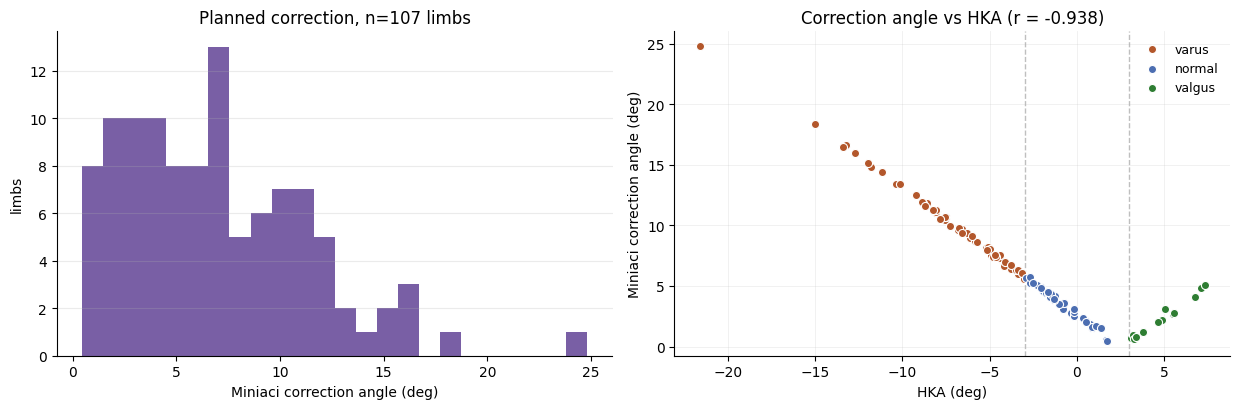

In [8]:
ca = LIMBS["corr_angle"].dropna().to_numpy(float)
print(f"Miniaci correction angle over {len(ca)} limbs: "
      f"mean {ca.mean():.2f} +/- {ca.std(ddof=1):.2f} deg, "
      f"median {np.median(ca):.2f}, range [{ca.min():.2f}, {ca.max():.2f}]")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.2))
axA.hist(ca, bins=24, color=PALETTE["training"], alpha=0.9)
axA.set_xlabel("Miniaci correction angle (deg)"); axA.set_ylabel("limbs")
axA.set_title(f"Planned correction, n={len(ca)} limbs")
axA.spines[["top", "right"]].set_visible(False); axA.grid(axis="y", alpha=0.25)

sub = LIMBS.dropna(subset=["corr_angle", "hka"])
for c in CLASSES:
    s = sub[sub["deformity"] == c]
    if len(s):
        axB.scatter(s["hka"], s["corr_angle"], s=34, color=PALETTE[c],
                    edgecolor="white", linewidth=0.8, label=c, zorder=3)
for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
    axB.axvline(cut, color="0.75", lw=1, ls="--", zorder=0)
if len(sub) > 2:
    r = np.corrcoef(sub["hka"], sub["corr_angle"])[0, 1]
    axB.set_title(f"Correction angle vs HKA (r = {r:+.3f})")
else:
    axB.set_title("Correction angle vs HKA")
axB.set_xlabel("HKA (deg)"); axB.set_ylabel("Miniaci correction angle (deg)")
axB.legend(frameon=False, fontsize=9); axB.grid(alpha=0.2, lw=0.6)
axB.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_correction_angle.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9 · Training Domain vs the OAI Validation Cohort

The figure the external-validation section needs. It answers one question: **how much of the OAI
cohort lies inside the alignment range the model was trained on?** Everything the stratified
validation notebook says about in-domain versus extrapolation is a claim about this overlap, and
until now it has been asserted rather than shown.

OAI cohort loaded from oai_deformity_stratified/knee_results.csv: 7172 knees
Compression refitted from the OAI predictions: pred = -0.559 + 0.806*true  ->  fixed point -2.89 deg
DOMAIN OVERLAP   training HKA range [-21.61, +7.32] deg, 107 limbs
  OAI stratum    knees  inside range  median gap  max gap  training limbs
  varus           2007        100.0%       0.00d    0.00d              59
  normal          4533        100.0%       0.00d    0.00d              34
  valgus           632         88.6%       1.18d   11.54d              14

  99.0% of all 7172 OAI knees fall inside the training HKA range.
  Training limbs per class: {'varus': 59, 'normal': 34, 'valgus': 14}
  Model compression fixed point (from the OAI run): -2.89 deg — inside the training range.


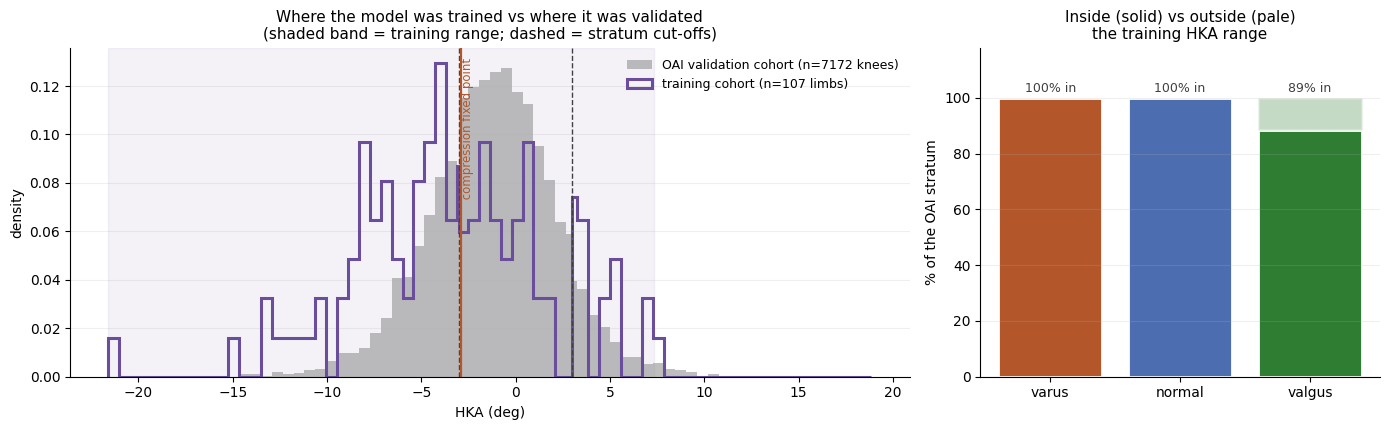

In [9]:
oai, oai_pred = None, None
for p in OAI_CANDIDATES:
    if not os.path.exists(p):
        continue
    df = pd.read_csv(p)
    if "oai_hka" in df.columns:
        keep = df[~df["flagged"]] if "flagged" in df.columns else df
        oai  = keep["oai_hka"].dropna().to_numpy(float)
        if "pred_hka" in keep.columns:
            both = keep.dropna(subset=["oai_hka", "pred_hka"])
            oai_pred = (both["oai_hka"].to_numpy(float), both["pred_hka"].to_numpy(float))
    elif {"hka_side1", "hka_side2"}.issubset(df.columns):
        oai = pd.concat([pd.to_numeric(df["hka_side1"], errors="coerce"),
                         pd.to_numeric(df["hka_side2"], errors="coerce")]).dropna().to_numpy(float)
    if oai is not None:
        print(f"OAI cohort loaded from {p}: {len(oai)} knees"); break

# The angle the model is unbiased at: fit pred = a + lam*true, fixed point = a/(1-lam).
# Prefer the value the validation notebook already exported; otherwise refit it here.
FIXED_PT = np.nan
if os.path.exists(OAI_SUMMARY_JSON):
    try:
        FIXED_PT = float(json.load(open(OAI_SUMMARY_JSON))["compression"]["fixed_point"])
    except Exception:
        pass
if not np.isfinite(FIXED_PT) and oai_pred is not None and len(oai_pred[0]) > 10:
    _lam, _a = np.polyfit(oai_pred[0], oai_pred[1], 1)
    if abs(1 - _lam) > 1e-6:
        FIXED_PT = float(_a / (1 - _lam))
        print(f"Compression refitted from the OAI predictions: pred = {_a:+.3f} + {_lam:.3f}*true"
              f"  ->  fixed point {FIXED_PT:+.2f} deg")

if oai is None:
    print("No OAI table found — set OAI_CANDIDATES to compare the two cohorts.")
    COVERAGE = pd.DataFrame()
else:
    lo, hi = float(h.min()), float(h.max())
    oai_cls = np.array([classify(v) for v in oai])
    rows = []
    for c in CLASSES:
        m = oai_cls == c
        if not m.any():
            continue
        v = oai[m]
        inside = (v >= lo) & (v <= hi)
        dist = np.where(inside, 0.0, np.minimum(np.abs(v - lo), np.abs(v - hi)))
        rows.append(dict(stratum=c, oai_knees=int(m.sum()),
                         pct_inside_training_range=100 * inside.mean(),
                         median_dist_outside=float(np.median(dist[~inside])) if (~inside).any() else 0.0,
                         max_dist_outside=float(dist.max()),
                         training_limbs=int((LIMBS["deformity"] == c).sum())))
    COVERAGE = pd.DataFrame(rows)

    print("=" * 92)
    print(f"DOMAIN OVERLAP   training HKA range [{lo:+.2f}, {hi:+.2f}] deg, {len(LIMBS)} limbs")
    print("=" * 92)
    print(f"  {'OAI stratum':12s} {'knees':>7s} {'inside range':>13s} {'median gap':>11s} "
          f"{'max gap':>8s} {'training limbs':>15s}")
    for _, r in COVERAGE.iterrows():
        print(f"  {r['stratum']:12s} {int(r['oai_knees']):7d} "
              f"{r['pct_inside_training_range']:12.1f}% {r['median_dist_outside']:10.2f}d "
              f"{r['max_dist_outside']:7.2f}d {int(r['training_limbs']):15d}")
    tot_inside = 100 * ((oai >= lo) & (oai <= hi)).mean()
    print(f"\n  {tot_inside:.1f}% of all {len(oai)} OAI knees fall inside the training HKA range.")
    print(f"  Training limbs per class: "
          f"{ {c: int((LIMBS['deformity'] == c).sum()) for c in CLASSES} }")
    if np.isfinite(FIXED_PT):
        print(f"  Model compression fixed point (from the OAI run): {FIXED_PT:+.2f} deg "
              f"— {'inside' if lo <= FIXED_PT <= hi else 'OUTSIDE'} the training range.")
    print("=" * 92)

    # ---------------- figure ----------------
    fig, (axO, axS) = plt.subplots(1, 2, figsize=(14, 4.4),
                                   gridspec_kw={"width_ratios": [2.1, 1]})
    edges = np.union1d(np.histogram_bin_edges(np.r_[oai, h], bins=70),
                       [NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND])
    axO.hist(oai, bins=edges, density=True, color=PALETTE["oai"], alpha=0.55,
             label=f"OAI validation cohort (n={len(oai)} knees)")
    axO.hist(h, bins=edges, density=True, histtype="step", lw=2.2,
             color=PALETTE["training"], label=f"training cohort (n={len(LIMBS)} limbs)")
    axO.axvspan(lo, hi, color=PALETTE["training"], alpha=0.07, zorder=0)
    for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
        axO.axvline(cut, color="0.25", ls="--", lw=1)
    if np.isfinite(FIXED_PT):
        axO.axvline(FIXED_PT, color="#B3572B", lw=1.6)
        axO.text(FIXED_PT, 0.97, " compression fixed point", rotation=90, fontsize=8.5,
                 color="#B3572B", va="top", ha="left", transform=axO.get_xaxis_transform())
    axO.set_xlabel("HKA (deg)"); axO.set_ylabel("density")
    axO.set_title("Where the model was trained vs where it was validated\n"
                  "(shaded band = training range; dashed = stratum cut-offs)", fontsize=11)
    axO.legend(frameon=False, fontsize=9); axO.grid(axis="y", alpha=0.2)
    axO.spines[["top", "right"]].set_visible(False)

    ins = COVERAGE["pct_inside_training_range"].to_numpy()
    axS.bar(COVERAGE["stratum"], ins, color=[PALETTE[c] for c in COVERAGE["stratum"]],
            edgecolor="white", linewidth=2)
    axS.bar(COVERAGE["stratum"], 100 - ins, bottom=ins,
            color=[PALETTE[c] for c in COVERAGE["stratum"]], alpha=0.28,
            edgecolor="white", linewidth=2)
    for i, v in enumerate(ins):
        axS.text(i, 101, f"{v:.0f}% in", ha="center", va="bottom", fontsize=9, color="0.25")
    axS.set_ylim(0, 118); axS.set_ylabel("% of the OAI stratum")
    axS.set_title("Inside (solid) vs outside (pale)\nthe training HKA range", fontsize=11)
    axS.spines[["top", "right"]].set_visible(False); axS.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "domain_overlap.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 10 · Composition by Split

In [10]:
SPLITS = (LIMBS.pivot_table(index="split", columns="deformity", values="hka",
                            aggfunc="size", observed=False, fill_value=0)
                .reindex(["train", "val", "test"]).fillna(0).astype(int))
SPLITS["limbs"] = SPLITS.sum(axis=1)
for col in ("hka_mean", "hka_min", "hka_max"):
    agg = {"hka_mean": "mean", "hka_min": "min", "hka_max": "max"}[col]
    SPLITS[col] = LIMBS.groupby("split")["hka"].agg(agg).reindex(SPLITS.index)

print("Limbs per split (the same deterministic 80/10/10 the training notebook uses):")
print(SPLITS.round(2).to_string())
print("\nA split whose HKA range differs from the others makes the fixed-split test set "
      "non-representative; cross-validation over all radiographs is the check on that.")
SPLITS

Limbs per split (the same deterministic 80/10/10 the training notebook uses):
deformity  varus  normal  valgus  limbs  hka_mean  hka_min  hka_max
split                                                              
train         43      32      10     85     -3.26   -21.61     7.32
val            8       0       2     10     -6.16   -15.02     5.56
test           8       2       2     12     -3.12    -8.70     4.65

A split whose HKA range differs from the others makes the fixed-split test set non-representative; cross-validation over all radiographs is the check on that.


deformity,varus,normal,valgus,limbs,hka_mean,hka_min,hka_max
split,,,,,,,
train,43,32,10,85,-3.264448,-21.606278,7.316518
val,8,0,2,10,-6.164587,-15.015465,5.561682
test,8,2,2,12,-3.123624,-8.699368,4.648409


## 11 · Band Sensitivity

In [11]:
sweep = []
for band in BAND_SWEEP:
    lab = np.array([classify(v, band=band) for v in LIMBS["hka"]])
    for c in CLASSES:
        m = lab == c
        sweep.append(dict(band=band, deformity=c, limbs=int(m.sum()),
                          pct=100 * m.mean() if len(lab) else np.nan))
SWEEP = pd.DataFrame(sweep)

print(f"  {'band':>5s}  " + "  ".join(f"{c:>16s}" for c in CLASSES))
for band in BAND_SWEEP:
    g = SWEEP[SWEEP["band"] == band].set_index("deformity")
    print(f"  {band:5.1f}  " + "  ".join(
        f"{int(g.loc[c, 'limbs']):6d} ({g.loc[c, 'pct']:5.1f}%)" for c in CLASSES))
print("\nIf the cohort stays single-class across every band, the 'trained on varus only' "
      "claim does not depend on where the neutral cut-off is drawn.")

   band             varus            normal            valgus
    1.0      76 ( 71.0%)      13 ( 12.1%)      18 ( 16.8%)
    2.0      66 ( 61.7%)      27 ( 25.2%)      14 ( 13.1%)
    3.0      59 ( 55.1%)      34 ( 31.8%)      14 ( 13.1%)
    4.0      52 ( 48.6%)      47 ( 43.9%)       8 (  7.5%)
    5.0      38 ( 35.5%)      63 ( 58.9%)       6 (  5.6%)

If the cohort stays single-class across every band, the 'trained on varus only' claim does not depend on where the neutral cut-off is drawn.


## 12 · Exports

In [12]:
exports = {"training_limbs.csv": LIMBS,
           "class_summary.csv":  summary,
           "split_composition.csv": SPLITS.reset_index(),
           "band_sweep.csv":     SWEEP}
if len(IO_PAIRS):
    exports["interobserver_hka.csv"] = IO_PAIRS
if len(COVERAGE):
    exports["domain_overlap.csv"] = COVERAGE
if len(LAT_FLIPS):
    exports["laterality_flips.csv"] = LAT_FLIPS
for fn, df in exports.items():
    df.to_csv(os.path.join(OUT_DIR, fn), index=False)

headline = dict(
    annotations=COCO_JSON_PATH,
    radiographs=int(LIMBS["file_name"].nunique()), limbs=int(len(LIMBS)),
    neutral_band_deg=NEUTRAL_BAND,
    hka=dict(mean=round(float(h.mean()), 3), sd=round(float(h.std(ddof=1)), 3),
             min=round(float(h.min()), 3), max=round(float(h.max()), 3),
             median=round(float(np.median(h)), 3),
             p5=round(float(np.percentile(h, 5)), 3),
             p95=round(float(np.percentile(h, 95)), 3)),
    class_counts={c: int((LIMBS["deformity"] == c).sum()) for c in CLASSES},
    classes_absent=[c for c in CLASSES if int((LIMBS["deformity"] == c).sum()) == 0],
    correction_angle=dict(mean=round(float(np.nanmean(LIMBS['corr_angle'])), 3),
                          min=round(float(np.nanmin(LIMBS['corr_angle'])), 3),
                          max=round(float(np.nanmax(LIMBS['corr_angle'])), 3)),
    interobserver_hka_sd=None if not np.isfinite(io_sd) else round(float(io_sd), 4),
    interobserver_hka_icc=None if not np.isfinite(io_icc) else round(float(io_icc), 4),
    laterality_flips=int(len(LAT_FLIPS)),
)
if len(COVERAGE):
    headline["domain_overlap"] = {r["stratum"]: dict(
        oai_knees=int(r["oai_knees"]),
        pct_inside_training_range=round(float(r["pct_inside_training_range"]), 2),
        training_limbs=int(r["training_limbs"])) for _, r in COVERAGE.iterrows()}
with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:
    json.dump(headline, f, indent=2)

print(f"Wrote {len(exports) + 1} files + figures to {os.path.abspath(OUT_DIR)}:")
for fn in list(exports) + ["summary.json"]:
    print(f"  {fn}")

Wrote 7 files + figures to /tf/notebooks/training_cohort_deformity:
  training_limbs.csv
  class_summary.csv
  split_composition.csv
  band_sweep.csv
  interobserver_hka.csv
  domain_overlap.csv
  summary.json


## 13 · Verification

Geometric invariances checked on the real annotations, not on synthetic probes: HKA must be
unchanged by isotropic scaling and translation (it is an angle) and by mirroring the image
horizontally (the medial/lateral reference in `hka_from_side` exists precisely so the left and
right limbs agree). Anything that fails here invalidates the distribution above.

In [13]:
problems = []
def check(cond, msg):
    if not cond: problems.append(msg)

# --- 1. bookkeeping ---
check(not LIMBS.duplicated(["file_name", "hemisphere"]).any(), "a limb appears twice")
check(int(summary["limbs"].sum()) == len(LIMBS), "class counts do not sum to the limb total")
check(LIMBS["deformity"].isna().sum() == 0, "a limb has no class")
check(all(classify(v) == d for v, d in zip(LIMBS["hka"], LIMBS["deformity"])),
      "a class label disagrees with classify()")
check(int(SPLITS["limbs"].sum()) == len(LIMBS), "split counts do not sum to the limb total")
check(train_end == int(n * SPLIT_RATIOS[0]),
      "the split reproduction drifted from the training notebook's rule")

# --- 2. HKA is invariant to similarity transforms of the landmarks ---
rng = np.random.default_rng(0)
worst_sim = worst_mir = 0.0
for s in valid_samples:
    for base in (0, 6):
        p = limb_points(s["slots"], base)
        if np.isnan(p[[0, 1, 3, 4, 5]]).any():
            continue
        ref = hka_from_side(p)
        k, tx, ty = float(rng.uniform(0.5, 2.0)), float(rng.uniform(-800, 800)), float(rng.uniform(-800, 800))
        worst_sim = max(worst_sim, abs(hka_from_side(p * k + np.array([tx, ty])) - ref))
        mir = p.copy(); mir[:, 0] = s["width"] - mir[:, 0]           # horizontal mirror
        worst_mir = max(worst_mir, abs(hka_from_side(mir) - ref))
check(worst_sim < 1e-6, f"HKA changed under scale+translate (max {worst_sim:.2e} deg)")
check(worst_mir < 1e-6, f"HKA changed under horizontal mirroring (max {worst_mir:.2e} deg)")

# --- 3. is `keypoints` really the mean of the three specialists? ---
mean_gap = np.nan
if HAS_SPECIALISTS:
    gaps = []
    for a in coco.get("annotations", []):
        if not all(f in a for f in SPECIALIST_FIELDS):
            continue
        M = np.array([a[f] for f in SPECIALIST_FIELDS], float)
        g = np.array(a["keypoints"], float)
        vis = (M[:, 0::3] > 0).all(axis=0)
        if not vis.any():
            continue
        idx = np.repeat(vis, 3)
        gaps.append(float(np.abs(M.mean(axis=0)[idx] - g[idx]).max()))
    mean_gap = float(np.max(gaps)) if gaps else np.nan

# --- 4. the specialists' own HKA should straddle the ground-truth HKA ---
if HAS_SPECIALISTS:
    cols = [f"hka_{l}" for l in SPECIALIST_LABELS]
    C = LIMBS.dropna(subset=cols + ["hka"])
    if len(C):
        off = float(np.abs(C[cols].mean(axis=1) - C["hka"]).max())
        check(off < 2.0, f"HKA from the mean annotation is {off:.2f} deg from the mean of the "
                         f"per-specialist HKAs — larger than nonlinearity alone should give")

print("=" * 78)
if problems:
    print(f"VERIFICATION FAILED — {len(problems)} problem(s):")
    for p in problems: print("  x", p)
else:
    print("VERIFICATION PASSED")
    print(f"  {len(LIMBS)} limbs from {LIMBS['file_name'].nunique()} radiographs, "
          f"each classified exactly once")
    print(f"  HKA invariant to scale+translate (max drift {worst_sim:.1e} deg) "
          f"and to mirroring ({worst_mir:.1e} deg)")
    if np.isfinite(mean_gap):
        print(f"  ground-truth keypoints vs the mean of the three specialists: "
              f"max |diff| {mean_gap:.3f} px"
              + ("  (consistent with a three-observer mean)" if mean_gap < 1.0 else
                 "  (NOT a plain mean — check how the ground truth was built)"))
    print(f"  laterality flips: {len(LAT_FLIPS)}")
print("=" * 78)
assert not problems, problems

VERIFICATION PASSED
  107 limbs from 54 radiographs, each classified exactly once
  HKA invariant to scale+translate (max drift 2.8e-14 deg) and to mirroring (2.8e-14 deg)
  ground-truth keypoints vs the mean of the three specialists: max |diff| 25.063 px  (NOT a plain mean — check how the ground truth was built)
  laterality flips: 0


## 14 · What to Put in the Manuscript

**One sentence in *Dataset and ground truth*.** Report the cohort's alignment, not just its
indication: number of limbs, mean ± SD HKA, full range, and the class counts under the same ±3°
rule the external validation uses. Without it the "in-domain versus extrapolation" reading of the
OAI strata is an inference from the surgical indication — and the Mendeley record does not state
alignment either, so a referee cannot check it.

**The overlap figure belongs in *External validation*.** Section 9's left panel is the whole
argument in one image: the training range as a band, the OAI cohort behind it, the stratum
cut-offs, and the compression fixed point. It converts "we validated on a different cohort" into
"we validated on a cohort that is mostly outside the alignment range we trained on, and here is
how far outside."

**Use it to reorder the claims.** With the coverage table you can say which OAI stratum is
in-domain and quantify the rest, so the external-validation paragraph leads with the in-domain
number, then reports the extrapolation strata as transfer results. That is a stronger and more
falsifiable claim than "agreement was stable across the alignment range".

**Quote the inter-observer HKA SD from section 7 next to OAI's 0.30°.** They are the two ceilings
— one for the in-domain evaluation, one for the external — and they are computed the same way, so
they can sit in the same sentence. Note the manuscript's existing 0.30–0.33° figure is for the
*correction angle*; the HKA number here is a different quantity and should be labelled as such.

**Check the two diagnostics before quoting anything.** A non-zero laterality-flip count in
section 4 means some limbs have `knee_inner`/`knee_outer` reversed, which inverts their HKA sign
and would move them between classes. And if section 13 reports the ground truth is not the plain
mean of the three specialists, the "three-observer mean" wording in the methods needs revisiting.

**Report the correction-angle range too.** Section 8 gives the span of corrections the model was
trained to reproduce. A reader assessing whether the ±1.63° tolerance claim generalises needs to
know over what range of corrections it was established.